In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [8]:
df=pd.read_csv(r"E:\Visualization\Lab_main\Data\Hobby_Data.csv")
df.head(11)

,Olympiad_Participation,Scholarship,School,Fav_sub,Projects,Grasp_pow,Time_sprt,Medals,Career_sprt,Act_sprt,Fant_arts,Won_arts,Time_art,Predicted Hobby
0,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
1,Yes,Yes,Yes,Mathematics,Yes,3,2,No,No,No,No,No,1,Academics
2,Yes,Yes,Yes,Science,Yes,5,1,Yes,No,No,No,No,1,Academics
3,Yes,Yes,Yes,Mathematics,Yes,5,1,Yes,No,No,No,Maybe,3,Academics
4,Yes,Yes,Yes,Science,Yes,5,3,No,No,No,No,No,2,Academics
5,Yes,Yes,Yes,Mathematics,Yes,6,2,Yes,No,No,No,No,4,Academics
6,Yes,Yes,Yes,Science,Yes,3,5,No,No,No,No,No,2,Academics
7,Yes,Yes,Yes,Mathematics,No,5,2,No,No,No,No,Maybe,3,Academics
8,Yes,Yes,Yes,Science,Yes,3,2,Yes,No,No,No,No,1,Academics
9,Yes,Yes,Yes,Science,Yes,5,3,Yes,No,No,No,No,1,Academics


In [9]:
df.describe()

,Grasp_pow,Time_sprt,Time_art
count,1601.000000,1601.000000,1601.000000
mean,3.480325,3.033729,2.234229
std,1.006737,1.347725,1.266186
min,1.000000,1.000000,1.000000
25%,3.000000,2.000000,1.000000
50%,3.000000,3.000000,2.000000
75%,4.000000,4.000000,3.000000
max,6.000000,6.000000,6.000000


In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Cột số (numeric): {numeric_cols}")
print(f"Cột phân loại (categorical): {categorical_cols}")

Cột số (numeric): ['Grasp_pow', 'Time_sprt', 'Time_art']
Cột phân loại (categorical): ['Olympiad_Participation', 'Scholarship', 'School', 'Fav_sub', 'Projects', 'Medals', 'Career_sprt', 'Act_sprt', 'Fant_arts', 'Won_arts', 'Predicted Hobby']


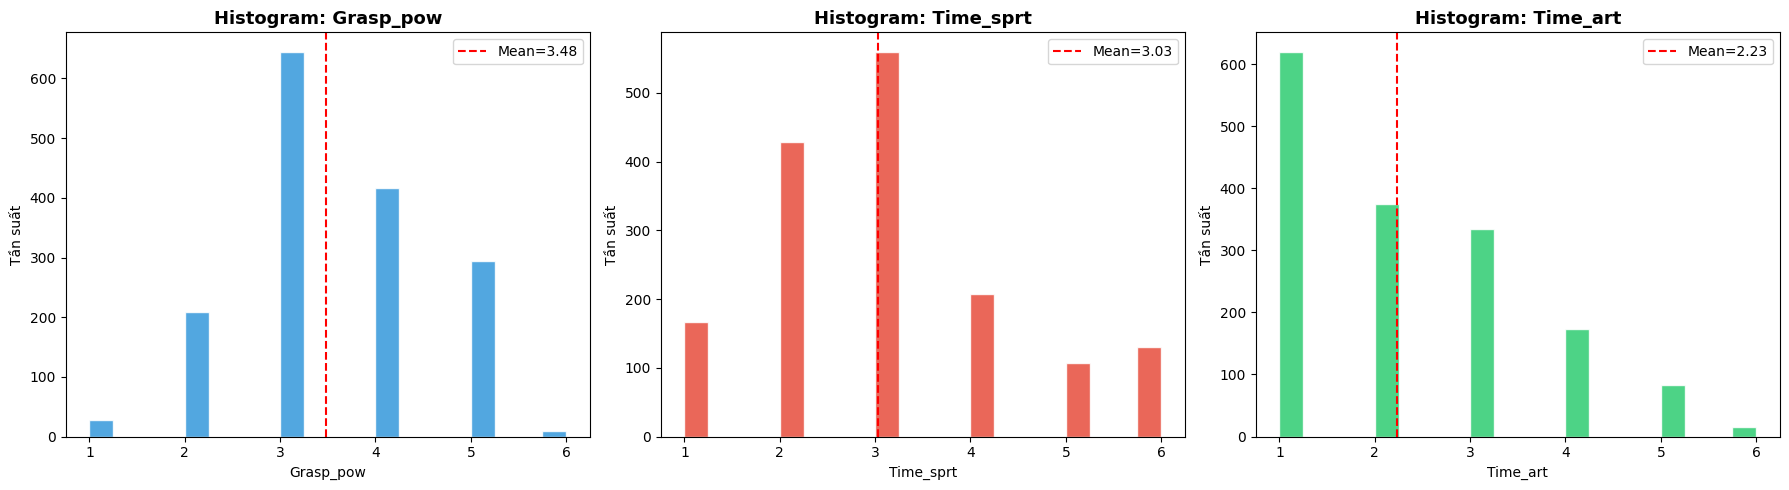

In [11]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 5))
if len(numeric_cols) == 1:
    axes = [axes]

colors = ["#3498db", "#e74c3c", "#2ecc71"]
for i, col in enumerate(numeric_cols):
    axes[i].hist(
        df[col], bins=20, color=colors[i % len(colors)], edgecolor="white", alpha=0.85
    )
    axes[i].set_title(f"Histogram: {col}", fontsize=13, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tần suất")
    axes[i].axvline(
        df[col].mean(), color="red", linestyle="--", label=f"Mean={df[col].mean():.2f}"
    )
    axes[i].legend()

plt.tight_layout()
plt.show()

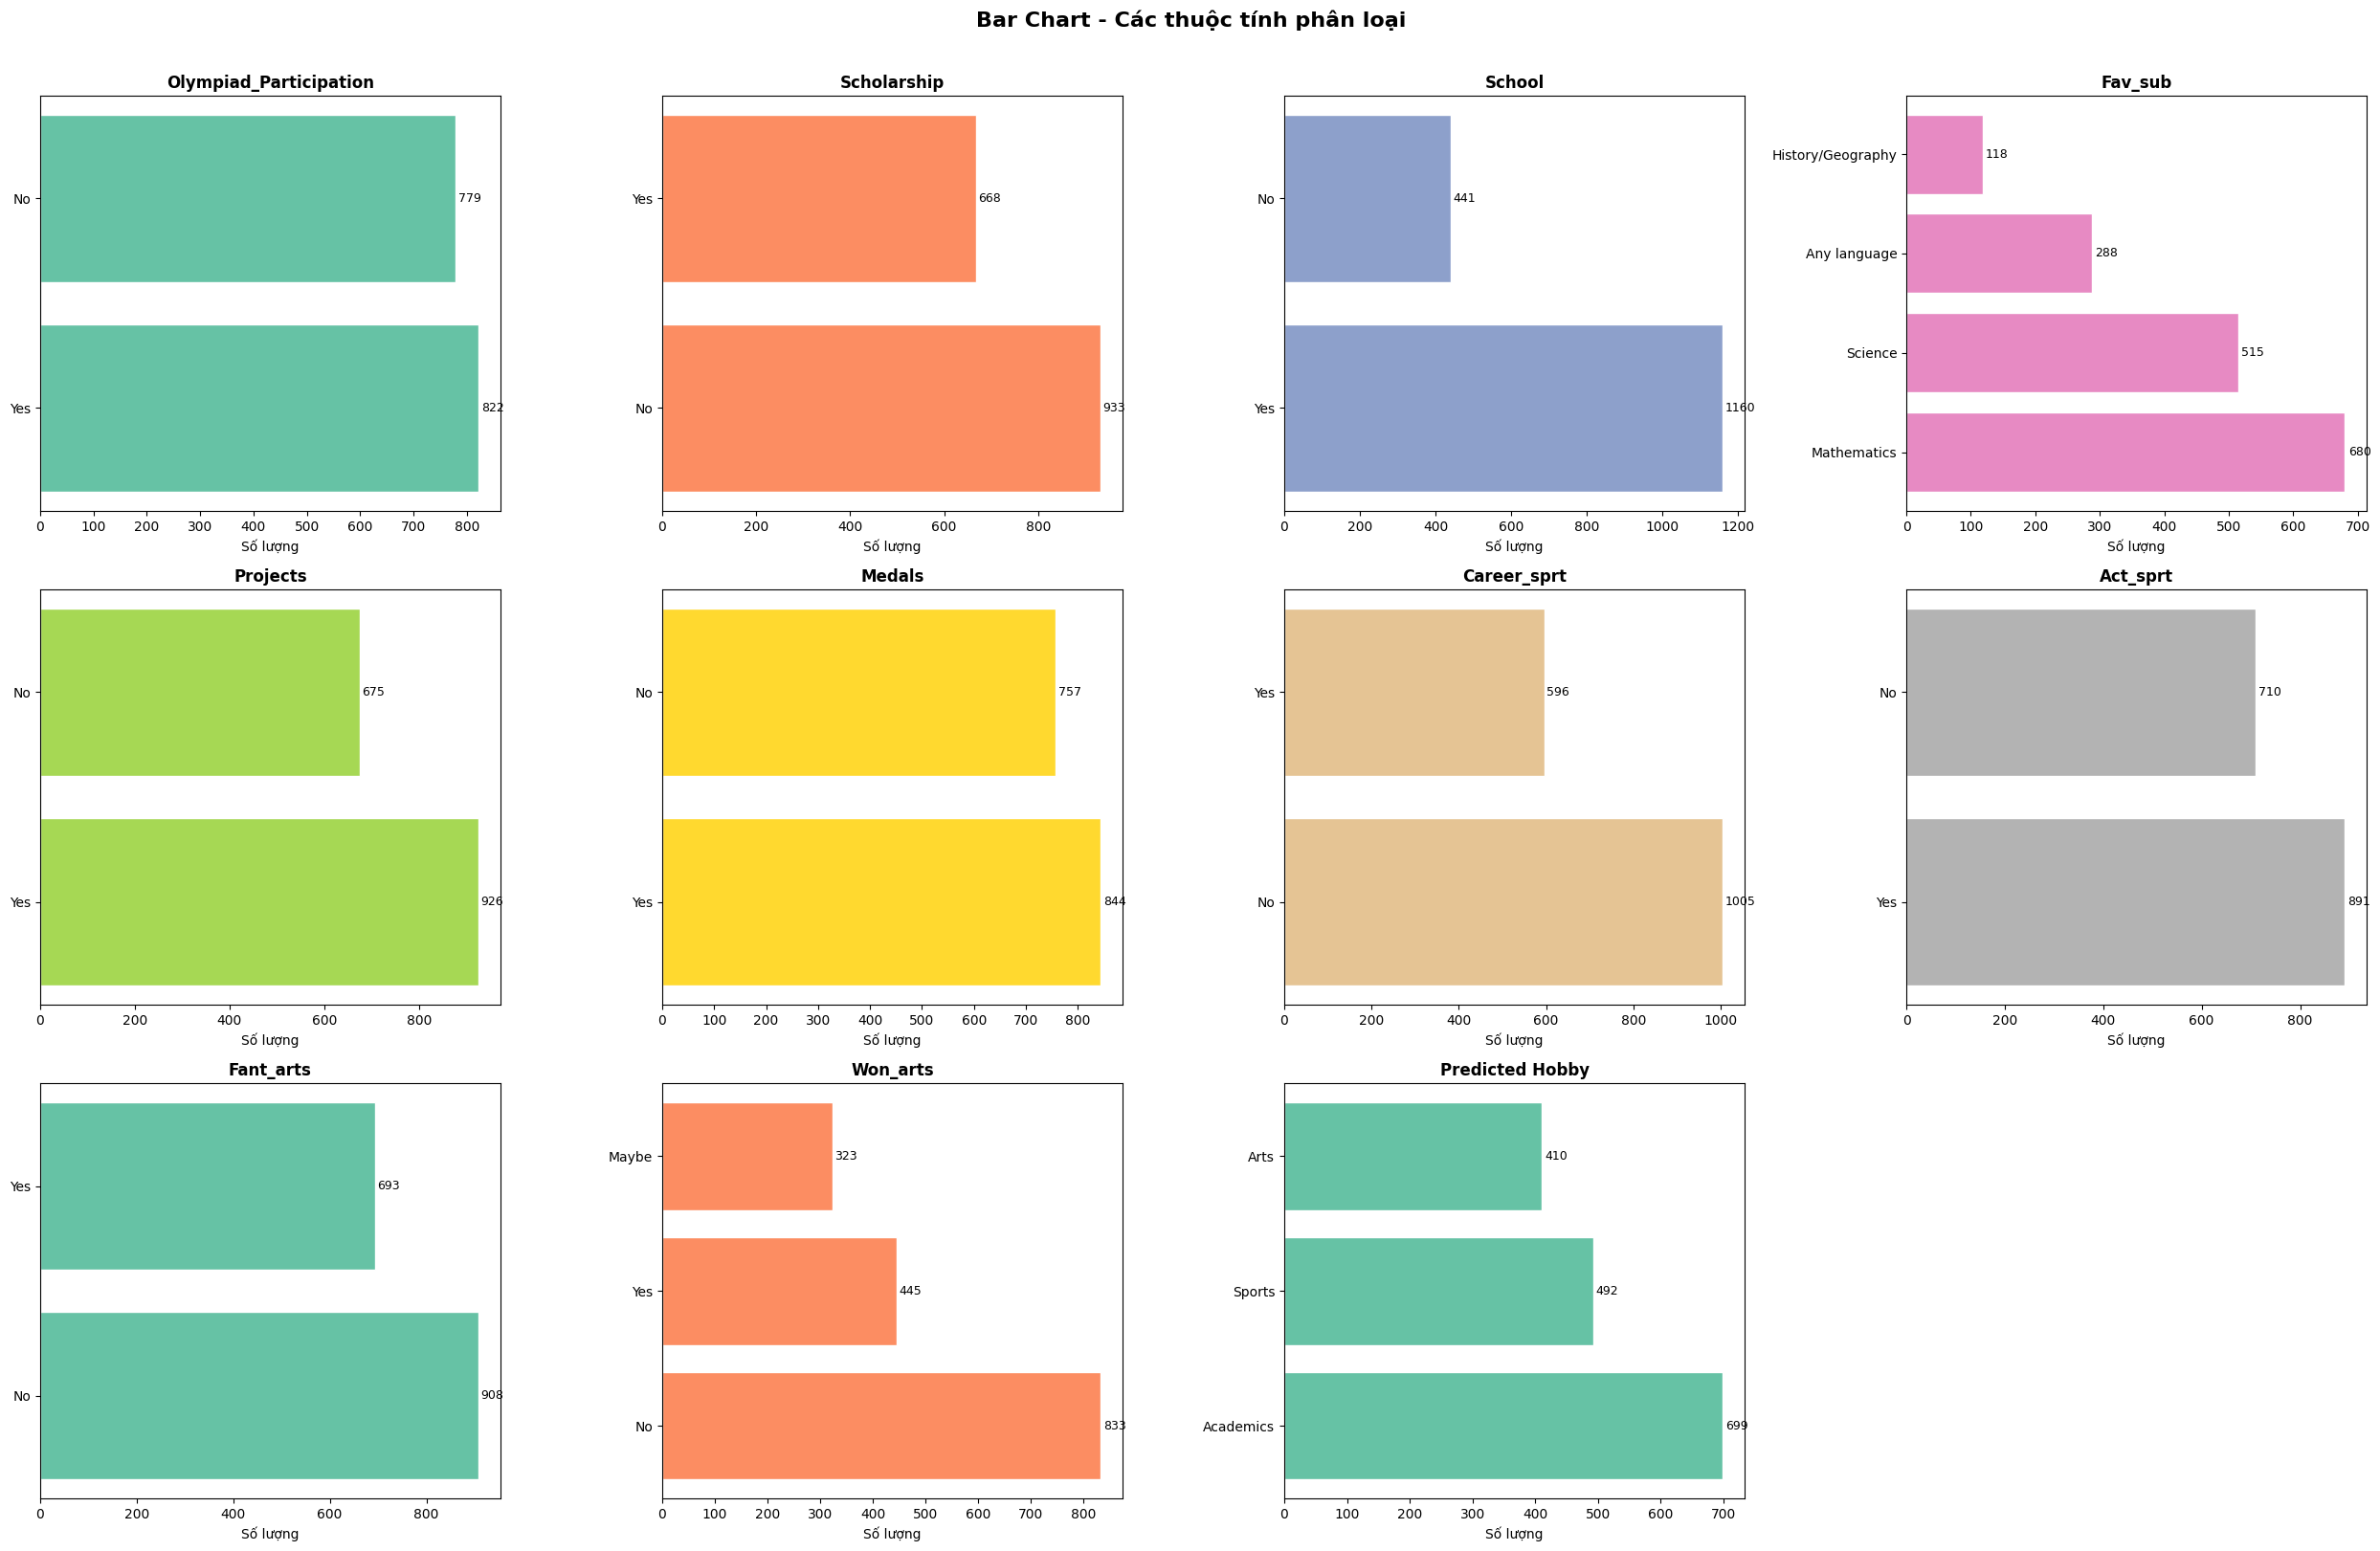

In [12]:
n_cat = len(categorical_cols)
fig, axes = plt.subplots(3, 4, figsize=(25, 16))
axes = axes.flatten()

palette = sns.color_palette("Set2", 10)
for i, col in enumerate(categorical_cols):
    counts = df[col].value_counts()
    axes[i].barh(
        counts.index.astype(str),
        counts.values,
        color=palette[i % len(palette)],
        edgecolor="white",
    )
    axes[i].set_title(f"{col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("Số lượng")
    for j, v in enumerate(counts.values):
        axes[i].text(v + 5, j, str(v), va="center", fontsize=9)

for k in range(n_cat, len(axes)):
    axes[k].set_visible(False)

plt.suptitle(
    "Bar Chart - Các thuộc tính phân loại", fontsize=16, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

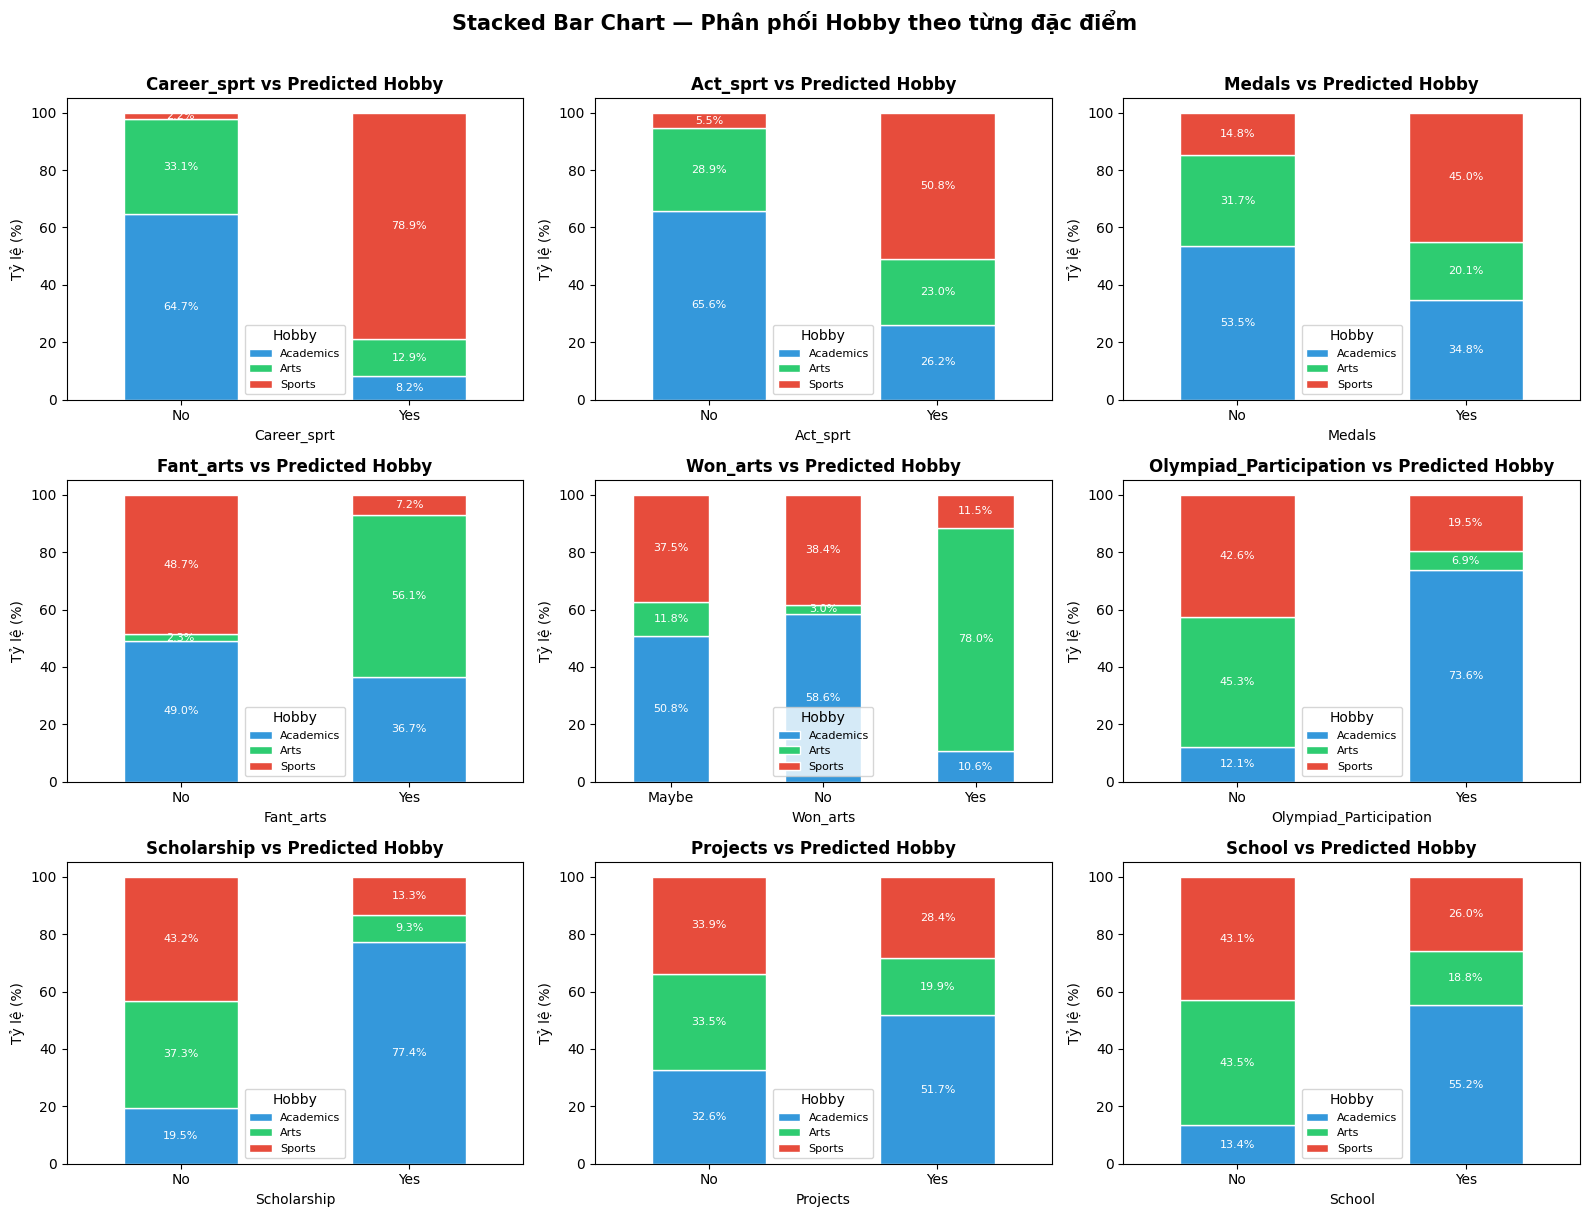

In [13]:
cols_to_plot = [
    "Career_sprt",
    "Act_sprt",
    "Medals",
    "Fant_arts",
    "Won_arts",
    "Olympiad_Participation",
    "Scholarship",
    "Projects",
    "School",
]

hobby_colors = {"Academics": "#3498db", "Sports": "#e74c3c", "Arts": "#2ecc71"}
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ct = pd.crosstab(df[col], df["Predicted Hobby"])
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100

    ct_pct.plot(
        kind="bar",
        stacked=True,
        ax=axes[i],
        color=[hobby_colors.get(c, "gray") for c in ct_pct.columns],
        edgecolor="white",
        width=0.5,
    )

    axes[i].set_title(f"{col} vs Predicted Hobby", fontsize=12, fontweight="bold")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Tỷ lệ (%)")

    # FIX: không hardcode, tự lấy số lượng label thực tế
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=0)
    axes[i].legend(title="Hobby", fontsize=8)

    for bar_group in axes[i].containers:
        axes[i].bar_label(
            bar_group, fmt="%.1f%%", label_type="center", fontsize=8, color="white"
        )

plt.suptitle(
    "Stacked Bar Chart — Phân phối Hobby theo từng đặc điểm",
    fontsize=15,
    fontweight="bold",
    y=1.01,
)
plt.tight_layout()
plt.show()

In [14]:
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Số lượng thiếu': missing, 'Tỷ lệ (%)': missing_pct})
print(missing_df.to_string())
print(f"Tổng giá trị thiếu: {df.isnull().sum().sum()}")

                        Số lượng thiếu  Tỷ lệ (%)
Olympiad_Participation               0        0.0
Scholarship                          0        0.0
School                               0        0.0
Fav_sub                              0        0.0
Projects                             0        0.0
Grasp_pow                            0        0.0
Time_sprt                            0        0.0
Medals                               0        0.0
Career_sprt                          0        0.0
Act_sprt                             0        0.0
Fant_arts                            0        0.0
Won_arts                             0        0.0
Time_art                             0        0.0
Predicted Hobby                      0        0.0
Tổng giá trị thiếu: 0


# BÀI 2: PHÁT HIỆN OUTLIERS TRONG DỮ LIỆU

# 3.1. Phương pháp IQR

In [15]:
outliers_iqr = {}
bounds = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (df[col] < lower) | (df[col] > upper)
    outliers_iqr[col] = mask
    bounds[col] = (lower, upper)

    print(f"\n  [{col}]")
    print(f"  Q1={Q1}, Q3={Q3}, IQR={IQR}")
    print(f"  Lower={lower:.2f}, Upper={upper:.2f}")
    print(f"  Outliers: {mask.sum()} ({mask.sum()/len(df)*100:.2f}%)")
    if mask.sum() > 0:
        print(f"  Giá trị: {sorted(df[col][mask].unique())}")


  [Grasp_pow]
  Q1=3.0, Q3=4.0, IQR=1.0
  Lower=1.50, Upper=5.50
  Outliers: 36 (2.25%)
  Giá trị: [np.int64(1), np.int64(6)]

  [Time_sprt]
  Q1=2.0, Q3=4.0, IQR=2.0
  Lower=-1.00, Upper=7.00
  Outliers: 0 (0.00%)

  [Time_art]
  Q1=1.0, Q3=3.0, IQR=2.0
  Lower=-2.00, Upper=6.00
  Outliers: 0 (0.00%)


# 3.2. Phương pháp Z-score

In [16]:
outliers_zscore = {}
z_threshold = 3

for col in numeric_cols:
    z_scores = np.abs(stats.zscore(df[col]))
    mask = z_scores > z_threshold
    outliers_zscore[col] = mask

    print(f"\n  [{col}] (threshold={z_threshold})")
    print(f"  Outliers: {mask.sum()} ({mask.sum()/len(df)*100:.2f}%)")
    if mask.sum() > 0:
        print(f"  Giá trị: {sorted(df[col][mask].unique())}")
        print(f"  Z-scores: {sorted(z_scores[mask].round(2))}")


  [Grasp_pow] (threshold=3)
  Outliers: 0 (0.00%)

  [Time_sprt] (threshold=3)
  Outliers: 0 (0.00%)

  [Time_art] (threshold=3)
  Outliers: 0 (0.00%)


# So sánh IQR vs Z-score

In [17]:
comparison_df = pd.DataFrame(
    [
        {
            "Cột": col,
            "Outliers (IQR)": outliers_iqr[col].sum(),
            "Outliers (Z-score)": outliers_zscore[col].sum(),
            "IQR %": f"{outliers_iqr[col].sum()/len(df)*100:.2f}%",
            "Z-score %": f"{outliers_zscore[col].sum()/len(df)*100:.2f}%",
        }
        for col in numeric_cols
    ]
)
print("\n", comparison_df.to_string(index=False))


       Cột  Outliers (IQR)  Outliers (Z-score) IQR % Z-score %
Grasp_pow              36                   0 2.25%     0.00%
Time_sprt               0                   0 0.00%     0.00%
 Time_art               0                   0 0.00%     0.00%


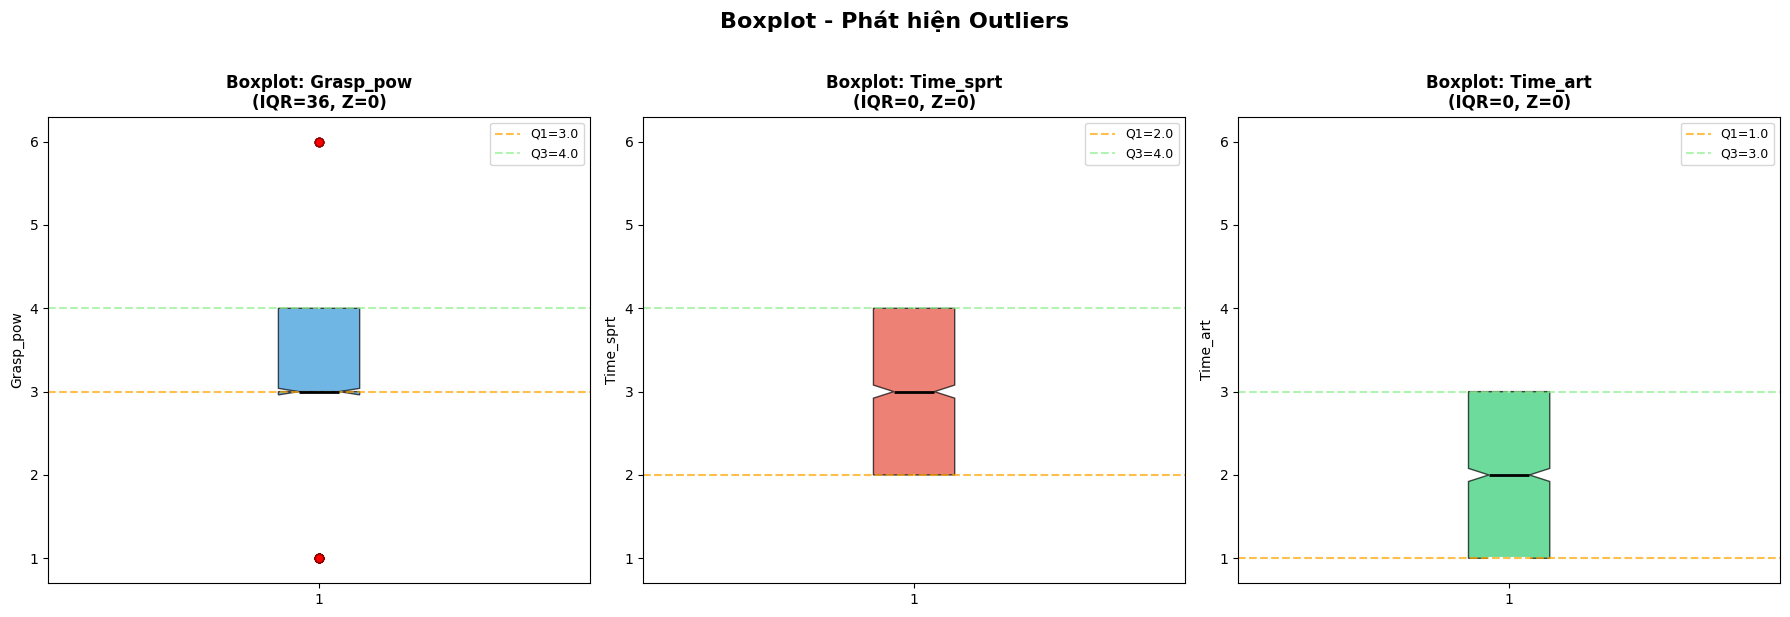

In [18]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(6 * len(numeric_cols), 6))
if len(numeric_cols) == 1:
    axes = [axes]

for i, col in enumerate(numeric_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    axes[i].boxplot(
        df[col],
        patch_artist=True,
        notch=True,
        whis=1.5,
        showfliers=True,
        boxprops=dict(facecolor=colors[i % len(colors)], alpha=0.7),
        flierprops=dict(
            marker="o",
            markerfacecolor="red",
            markersize=6,
            markeredgecolor="darkred",
            alpha=0.6,
        ),
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="white", linewidth=1.2),
        capprops=dict(color="white", linewidth=1.5),
    )
    axes[i].axhline(Q1, color="orange", linestyle="--", alpha=0.7, label=f"Q1={Q1}")
    axes[i].axhline(Q3, color="lightgreen", linestyle="--", alpha=0.7, label=f"Q3={Q3}")

    # FIX: giữ đủ range để thấy outlier dots
    axes[i].set_ylim(df[col].min() - 0.3, df[col].max() + 0.3)

    axes[i].set_title(
        f"Boxplot: {col}\n"
        f"(IQR={outliers_iqr[col].sum()}, Z={outliers_zscore[col].sum()})",
        fontsize=12,
        fontweight="bold",
    )
    axes[i].set_ylabel(col)
    axes[i].legend(fontsize=9)

plt.suptitle("Boxplot - Phát hiện Outliers", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

In [19]:
df_clean = df.copy()

In [20]:
for col in numeric_cols:
    median_val = df[col].median()  # tính trên df GỐC
    df_clean.loc[outliers_iqr[col], col] = median_val
    print(f"[{col}] thay {outliers_iqr[col].sum()} outliers → median={median_val}")

# ──────────────────────────────────────────────
# 8. Scatter Before vs After — FIX trục + jitter
# ──────────────────────────────────────────────
pairs = list(combinations(numeric_cols, 2))
fig, axes = plt.subplots(len(pairs), 2, figsize=(14, 5 * len(pairs)))

rng = np.random.default_rng(42)  # seed cố định → jitter tái lập được

for idx, (col_x, col_y) in enumerate(pairs):
    is_outlier = outliers_iqr[col_x] | outliers_iqr[col_y]
    normal = ~is_outlier

    # FIX: range thống nhất lấy từ df GỐC
    x_min, x_max = df[col_x].min() - 0.5, df[col_x].max() + 0.5
    y_min, y_max = df[col_y].min() - 0.5, df[col_y].max() + 0.5

    jitter = 0.07  # nhỏ vừa đủ để tách điểm chồng, không làm lệch ý nghĩa

    # ── Trái: TRƯỚC xử lý ──────────────────────
    ax = axes[idx][0]

    jx = rng.uniform(-jitter, jitter, normal.sum())
    jy = rng.uniform(-jitter, jitter, normal.sum())
    ax.scatter(
        df[col_x][normal] + jx,
        df[col_y][normal] + jy,
        color="#3498db",
        alpha=0.5,
        s=30,
        label="Normal",
        edgecolors="none",
    )
    ax.scatter(
        df[col_x][is_outlier],
        df[col_y][is_outlier],
        color="#e74c3c",
        alpha=0.9,
        s=90,
        marker="X",
        label=f"Outlier ({is_outlier.sum()})",
        linewidths=2,
    )
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"TRƯỚC — {col_x} vs {col_y}", fontsize=12, fontweight="bold")
    ax.set_xlabel(col_x)
    ax.set_ylabel(col_y)
    ax.legend()

    # ── Phải: SAU xử lý ────────────────────────
    ax2 = axes[idx][1]

    jx2 = rng.uniform(-jitter, jitter, normal.sum())
    jy2 = rng.uniform(-jitter, jitter, normal.sum())
    ax2.scatter(
        df_clean[col_x][normal] + jx2,
        df_clean[col_y][normal] + jy2,
        color="#2ecc71",
        alpha=0.5,
        s=30,
        label="Normal",
        edgecolors="none",
    )
    # Chỉ vẽ cam nếu thật sự có điểm bị thay
    if is_outlier.sum() > 0:
        ax2.scatter(
            df_clean[col_x][is_outlier],
            df_clean[col_y][is_outlier],
            color="darkorange",
            alpha=0.9,
            s=90,
            marker="o",
            label=f"Đã thay → median",
            linewidths=2,
        )
    ax2.set_xlim(x_min, x_max)  # FIX: cùng range với plot TRƯỚC
    ax2.set_ylim(y_min, y_max)
    ax2.set_title(f"SAU — {col_x} vs {col_y}", fontsize=12, fontweight="bold")
    ax2.set_xlabel(col_x)
    ax2.set_ylabel(col_y)
    ax2.legend()

plt.suptitle(
    "Outlier Treatment — Thay bằng Median (IQR)", fontsize=15, fontweight="bold", y=1.01
)
plt.tight_layout()
plt.show()

[Grasp_pow] thay 36 outliers → median=3.0
[Time_sprt] thay 0 outliers → median=3.0
[Time_art] thay 0 outliers → median=2.0


NameError: name 'combinations' is not defined

In [ ]:
print("So sánh df gốc vs df_clean")
for col in numeric_cols:
    print(f"[{col}]")
    print(f"  Mean : {df[col].mean():.4f} -> {df_clean[col].mean():.4f}")
    print(f"  Std: {df[col].std():.4f} -> {df_clean[col].std():.4f}")
    print(f"  Min: {df[col].min()}  -> {df_clean[col].min()}")
    print(f"  Max   : {df[col].max()} ->{df_clean[col].max()}")

So sánh df gốc vs df_clean
[Grasp_pow]
  Mean : 3.4803 -> 3.4972
  Std: 1.0067 -> 0.9375
  Min: 1  -> 2
  Max   : 6 ->5
[Time_sprt]
  Mean : 3.0337 -> 3.0337
  Std: 1.3477 -> 1.3477
  Min: 1  -> 1
  Max   : 6 ->6
[Time_art]
  Mean : 2.2342 -> 2.2342
  Std: 1.2662 -> 1.2662
  Min: 1  -> 1
  Max   : 6 ->6


In [21]:
corr_matrix= df.corr(numeric_only=True)
print(corr_matrix)

           Grasp_pow  Time_sprt  Time_art
Grasp_pow   1.000000  -0.053866 -0.228052
Time_sprt  -0.053866   1.000000  0.015878
Time_art   -0.228052   0.015878  1.000000


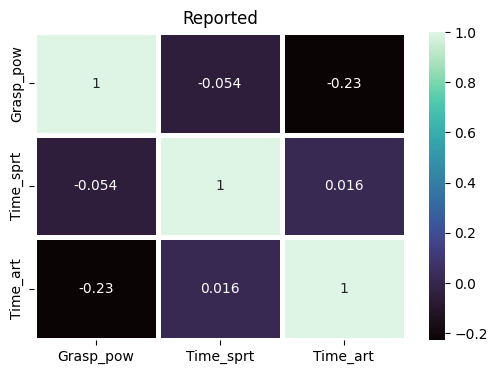

In [23]:
plt.figure(figsize=(6,4))
sns.heatmap(
    corr_matrix,
    annot=True,
    linewidths=3.5,
    linecolor='white',
    cmap='mako'
    
)
plt.title('Reported')
plt.show()